**Name: vinamra vijay mishra**


**roll number: DS253054**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


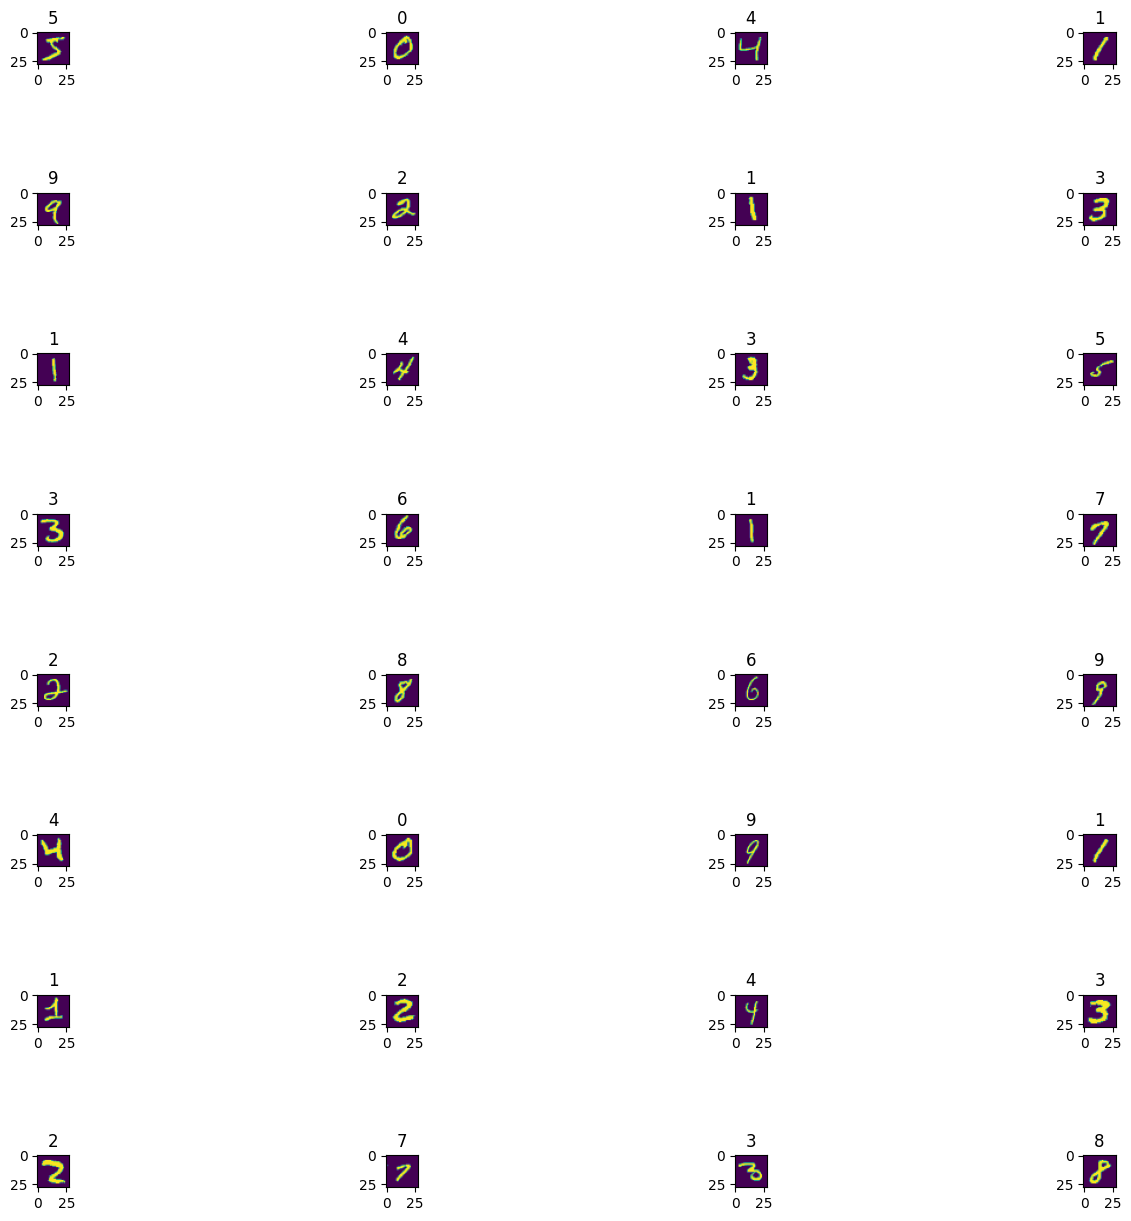

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 522)            │       409,770 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 348)            │       182,004 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 232)            │        80,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,072 (2.58 MB)

 Trainable params: 675,072 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.9056 - loss: 0.8983 - val_accuracy: 0.9472 - val_loss: 0.1987
Epoch 2/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9490 - loss: 0.1851 - val_accuracy: 0.9466 - val_loss: 0.1888
Epoch 3/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9599 - loss: 0.1432 - val_accuracy: 0.9563 - val_loss: 0.1536
Epoch 4/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9653 - loss: 0.1284 - val_accuracy: 0.9578 - val_loss: 0.1534
Epoch 5/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - accuracy: 0.9690 - loss: 0.1135 - val_accuracy: 0.9660 - val_loss: 0.1436
Epoch 6/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9748 - loss: 0.0974 - val_accuracy: 0.9685 - val_loss: 0.1447
Epoch 7/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.9772 - loss: 0.0896 - val_accuracy: 0.9766 - val_loss: 0.1049
Epoch 8/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 

In [1]:
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
from keras.layers import Input, Dense
from keras.datasets import mnist

# ── 1. Load MNIST ──────────────────────────────────────────────
(img_tr, lbl_tr), (img_test, lbl_test) = mnist.load_data()

# ── 2. Visualize samples ───────────────────────────────────────
plt.figure(figsize=(15, 15))
for i in range(32):
    plt.subplot(8, 4, i+1)
    plt.subplots_adjust(hspace=4.0, wspace=2.0)
    plt.imshow(img_tr[i])
    plt.title(lbl_tr[i])
plt.show()

# ── 3. Build ANN ───────────────────────────────────────────────
input_layer   = Input(shape=(784,))
hidden_layer1 = Dense(522, activation="relu")(input_layer)
hidden_layer2 = Dense(348, activation="relu")(hidden_layer1)
hidden_layer3 = Dense(232, activation="relu")(hidden_layer2)
output_layer  = Dense(10,  activation="softmax")(hidden_layer3)
ann = keras.Model(inputs=input_layer, outputs=output_layer)
ann.summary()

# ── 4. Train ───────────────────────────────────────────────────
ann.compile(optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])
es = keras.callbacks.EarlyStopping(monitor="loss", verbose=1, patience=1)

img_tr_new   = np.reshape(img_tr,   (60000, 784))
img_test_new = np.reshape(img_test, (10000, 784))

ann.fit(img_tr_new, lbl_tr,
        validation_data=(img_test_new, lbl_test),
        epochs=200,
        callbacks=[es])

# ── 5. Test on MNIST sample ────────────────────────────────────
img = img_test_new[0].reshape(1, 784)
p = ann.predict(img)
print("Predicted:", np.argmax(p[0]), "| Actual:", lbl_test[0])


Upload your image now...


Saving 1.png to 1 (2).png
Uploaded: 1 (2).png


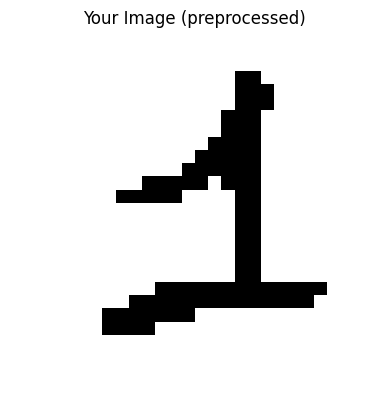

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Probabilities:
 [[5.38705150e-04 2.19702311e-02 1.38817668e-01 5.75375021e-01
  1.38760416e-03 1.08807944e-01 1.02967388e-05 1.43053066e-02
  7.43416995e-02 6.44455180e-02]]
Predicted Digit: 1


In [5]:
# ── 6. Upload your own image ───────────────────────────────────
from google.colab import files
print("Upload your image now...")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print("Uploaded:", filename)

# ── 7. Preprocess and predict ──────────────────────────────────
img_out = cv2.imread(f"/content/{filename}", cv2.IMREAD_GRAYSCALE)

if img_out is None:
    raise FileNotFoundError(f"Could not read /content/{filename} — upload may have failed")

img_out = cv2.resize(img_out, (28, 28))
_, img_out = cv2.threshold(img_out, 127, 255, cv2.THRESH_BINARY)
img_out = 255 - img_out

plt.imshow(img_out, cmap='gray')
plt.title("Your Image (preprocessed)")
plt.axis('off')
plt.show()

# ── these lines were missing ───────────────────────────────────
img_out_input = img_out.reshape(1, 784)
prediction = ann.predict(img_out_input)
print("Probabilities:\n", prediction)
print("Predicted Digit:", np.argmax(prediction))